# Federated Learning-Based Intrusion Detection System (IDS)

## Project Overview
This notebook presents a **Federated Learning-based Intrusion Detection System** for distributed network environments. The objective is to detect cyber-attacks while preserving data privacy by avoiding centralized data sharing.

## Notebook Goal
To build a reproducible pipeline covering:
- Data preprocessing  
- Federated model training  
- Model aggregation  
- Performance evaluation  
- Visualization of results  

## Dataset
- **Primary Dataset**: CIC-IDS 2017 (real-world network intrusion data)  
- Includes both **normal traffic and multiple attack types**

## Important Notes
- Data is split across multiple simulated **network clients**
- Only **model parameters** are shared (not raw data)
- Results are used for **dissertation analysis and evaluation**

## Workflow Summary
Data → Preprocessing → Federated Training → Model Aggregation → Evaluation → Visualization  

## Reproducibility
Random seeds and consistent configurations are used to ensure reproducible results.

## 1. Import Libraries and Configuration

In [30]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('All libraries imported successfully!')

# ====== CONFIGURATION ======
DATASET_DIR = '/kaggle/input/datasets/chethuhn/network-intrusion-dataset'

SAMPLE_FRACTION = 0.3
TEST_SIZE = 0.2
RANDOM_STATE = 42
NUM_ROUNDS = 5

# Network type mapping - each represents a different distributed network client
NETWORK_TYPES = {
    'Network_A (Normal Traffic)': [
        'Monday-WorkingHours.pcap_ISCX.csv'
    ],
    'Network_B (Brute Force)': [
        'Tuesday-WorkingHours.pcap_ISCX.csv'
    ],
    'Network_C (DoS/Heartbleed)': [
        'Wednesday-workingHours.pcap_ISCX.csv'
    ],
    'Network_D (Web Attacks/Infiltration)': [
        'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
        'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv'
    ],
    'Network_E (Botnet/PortScan/DDoS)': [
        'Friday-WorkingHours-Morning.pcap_ISCX.csv',
        'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
        'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'
    ]
}

print(f'Federated Clients: {len(NETWORK_TYPES)}')
print(f'Federated Rounds: {NUM_ROUNDS}')
print(f'Sample Fraction per Client: {SAMPLE_FRACTION}')

All libraries imported successfully!
Federated Clients: 5
Federated Rounds: 5
Sample Fraction per Client: 0.3


### Explanation:
This cell imports all required libraries for data processing, visualization, machine learning, and evaluation, and sets configurations for consistent results. It also defines key parameters and maps dataset files to simulate multiple federated network clients.

## 2. Data Loading

In [31]:
dataframes = []

# Check if files are inside a subfolder (common in Kaggle)
all_files = os.listdir(DATASET_DIR)

# If no CSV found directly, go one level deeper
if not any(file.endswith('.csv') for file in all_files):
    subfolders = [f for f in all_files if os.path.isdir(os.path.join(DATASET_DIR, f))]
    
    if len(subfolders) > 0:
        DATASET_DIR = os.path.join(DATASET_DIR, subfolders[0])
        print(f'Updated path to subfolder: {DATASET_DIR}')

# Load all CSV files
for file in sorted(os.listdir(DATASET_DIR)):
    if file.endswith('.csv'):
        filepath = os.path.join(DATASET_DIR, file)
        print(f'Loading: {file}...', end=' ')
        
        df = pd.read_csv(filepath, low_memory=False, encoding='latin1')
        df.columns = df.columns.str.strip()
        df['Source_File'] = file
        
        print(f'-> {len(df):,} rows')
        dataframes.append(df)

# Combine all data
data = pd.concat(dataframes, ignore_index=True)

print(f'\nTotal records: {data.shape[0]:,}')
print(f'Total features: {data.shape[1] - 2}')

Loading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv... -> 225,745 rows
Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv... -> 286,467 rows
Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv... -> 191,033 rows
Loading: Monday-WorkingHours.pcap_ISCX.csv... -> 529,918 rows
Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv... -> 288,602 rows
Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv... -> 170,366 rows
Loading: Tuesday-WorkingHours.pcap_ISCX.csv... -> 445,909 rows
Loading: Wednesday-workingHours.pcap_ISCX.csv... -> 692,703 rows

Total records: 2,830,743
Total features: 78


### Explanation:
In this step, we load all CSV files from the dataset directory, handling cases where files are stored inside subfolders. We then combine all files into a single dataset and track their source for further analysis.

## 3. Data Exploration

In [32]:
# Display first few rows
print('Dataset Shape:', data.shape)
print('\nColumn Data Types:')
print(data.dtypes.value_counts())
data.head()

Dataset Shape: (2830743, 80)

Column Data Types:
int64      54
float64    24
object      2
Name: count, dtype: int64


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Source_File
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


### Explanation:
Here, we explore the dataset by checking its shape and understanding the distribution of data types across columns. We also display the first few rows to get an initial overview of the data.

In [33]:
# Label distribution
print('Label Distribution:')
print('=' * 55)
label_counts = data['Label'].value_counts()
for label, count in label_counts.items():
    pct = count / len(data) * 100
    print(f'  {label:<35} {count:>10,}  ({pct:.2f}%)')

print(f'\nTotal Attack Types: {len(label_counts) - 1}')
print(f'Benign samples: {label_counts.get("BENIGN", 0):,}')
print(f'Attack samples: {len(data) - label_counts.get("BENIGN", 0):,}')

Label Distribution:
  BENIGN                               2,273,097  (80.30%)
  DoS Hulk                               231,073  (8.16%)
  PortScan                               158,930  (5.61%)
  DDoS                                   128,027  (4.52%)
  DoS GoldenEye                           10,293  (0.36%)
  FTP-Patator                              7,938  (0.28%)
  SSH-Patator                              5,897  (0.21%)
  DoS slowloris                            5,796  (0.20%)
  DoS Slowhttptest                         5,499  (0.19%)
  Bot                                      1,966  (0.07%)
  Web Attack ï¿½ Brute Force               1,507  (0.05%)
  Web Attack ï¿½ XSS                         652  (0.02%)
  Infiltration                                36  (0.00%)
  Web Attack ï¿½ Sql Injection                21  (0.00%)
  Heartbleed                                  11  (0.00%)

Total Attack Types: 14
Benign samples: 2,273,097
Attack samples: 557,646


### Explanation:
In this step, we analyze the distribution of different traffic labels to understand the proportion of normal and attack data. This helps identify class imbalance and the variety of attack types present in the dataset.

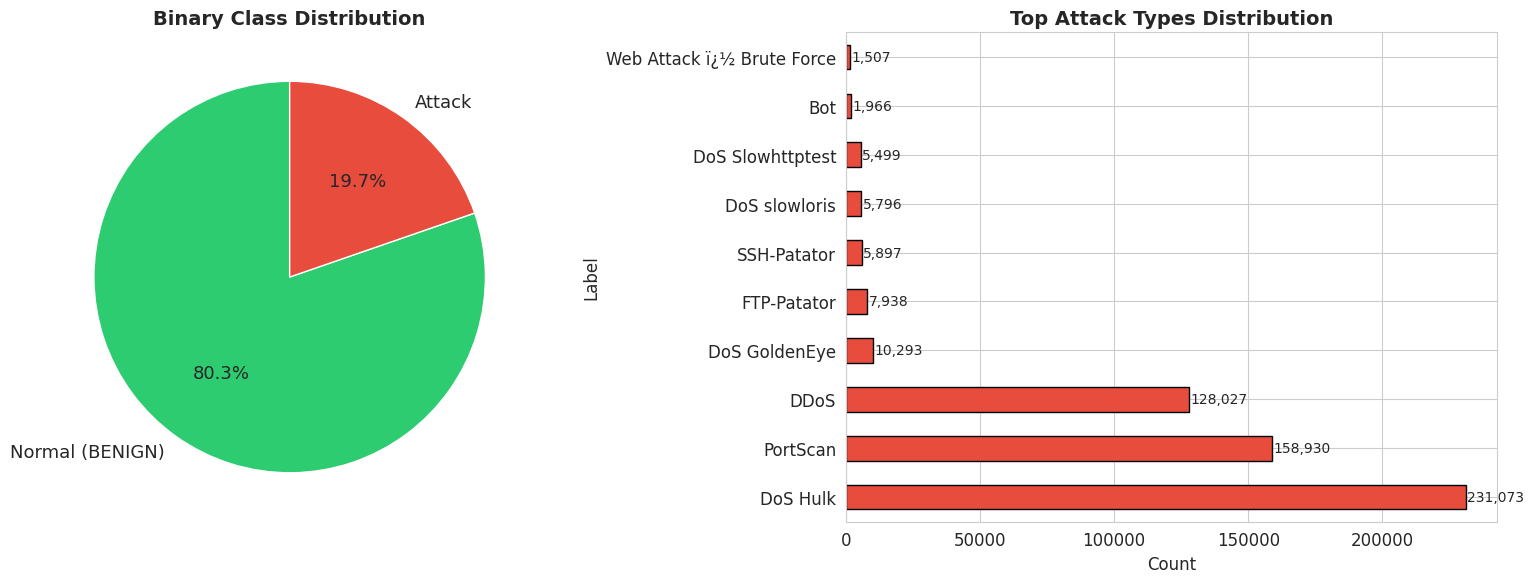

Saved: label_distribution.png


In [34]:
# Visualize label distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Binary distribution
binary_counts = pd.Series({
    'Normal (BENIGN)': label_counts.get('BENIGN', 0),
    'Attack': len(data) - label_counts.get('BENIGN', 0)
})
axes[0].pie(binary_counts, labels=binary_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90, textprops={'fontsize': 13})
axes[0].set_title('Binary Class Distribution', fontsize=14, fontweight='bold')

# Attack type distribution (top 10)
attack_counts = label_counts[label_counts.index != 'BENIGN'].head(10)
attack_counts.plot(kind='barh', ax=axes[1], color='#e74c3c', edgecolor='black')
axes[1].set_title('Top Attack Types Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Count')
for i, v in enumerate(attack_counts):
    axes[1].text(v + 500, i, f'{v:,}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: label_distribution.png')

### Explanation:
Here, we visualize the distribution of normal and attack traffic using a pie chart and display the most frequent attack types using a bar chart. This helps in understanding class imbalance and identifying dominant attack categories in the dataset.

## 4. Data Preprocessing

In [35]:
print('DATA PREPROCESSING')
print('=' * 55)
initial_rows = len(data)

# Store source files before preprocessing
source_files = data['Source_File'].copy()

# 1. Check for missing values
missing = data.isnull().sum()
missing_cols = missing[missing > 0]
print(f'Columns with missing values: {len(missing_cols)}')

# 2. Check for infinite values
numeric_cols = data.select_dtypes(include=[np.number]).columns
inf_count = np.isinf(data[numeric_cols]).sum().sum()
print(f'Infinite values found: {inf_count:,}')

# 3. Replace infinite values with NaN then drop
data[numeric_cols] = data[numeric_cols].replace([np.inf, -np.inf], np.nan)
data = data.dropna()
source_files = source_files.loc[data.index]
print(f'Dropped {initial_rows - len(data):,} rows with missing/infinite values')
print(f'Remaining rows: {len(data):,}')

# 4. Create binary label: Normal=0, Attack=1
data['Binary_Label'] = (data['Label'] != 'BENIGN').astype(int)
print(f'\nBinary Labels -> Normal: {(data["Binary_Label"]==0).sum():,}, Attack: {(data["Binary_Label"]==1).sum():,}')

# 5. Identify feature columns
exclude_cols = ['Label', 'Binary_Label', 'Source_File']
feature_cols = [c for c in data.columns if c not in exclude_cols]

# 6. Ensure all features are numeric
for col in feature_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')
data = data.dropna(subset=feature_cols)
source_files = source_files.loc[data.index]

print(f'Final feature count: {len(feature_cols)}')
print(f'Final dataset size: {len(data):,}')

DATA PREPROCESSING
Columns with missing values: 1
Infinite values found: 4,376
Dropped 2,867 rows with missing/infinite values
Remaining rows: 2,827,876

Binary Labels -> Normal: 2,271,320, Attack: 556,556
Final feature count: 78
Final dataset size: 2,827,876


### Explanation:
- In this step, we perform data preprocessing by checking and handling missing and infinite values  
- Convert all features into numeric format and remove invalid rows to ensure data quality  
- Create a binary label (Normal = 0, Attack = 1) for classification  
- Identify relevant feature columns and finalize the cleaned dataset for model training  

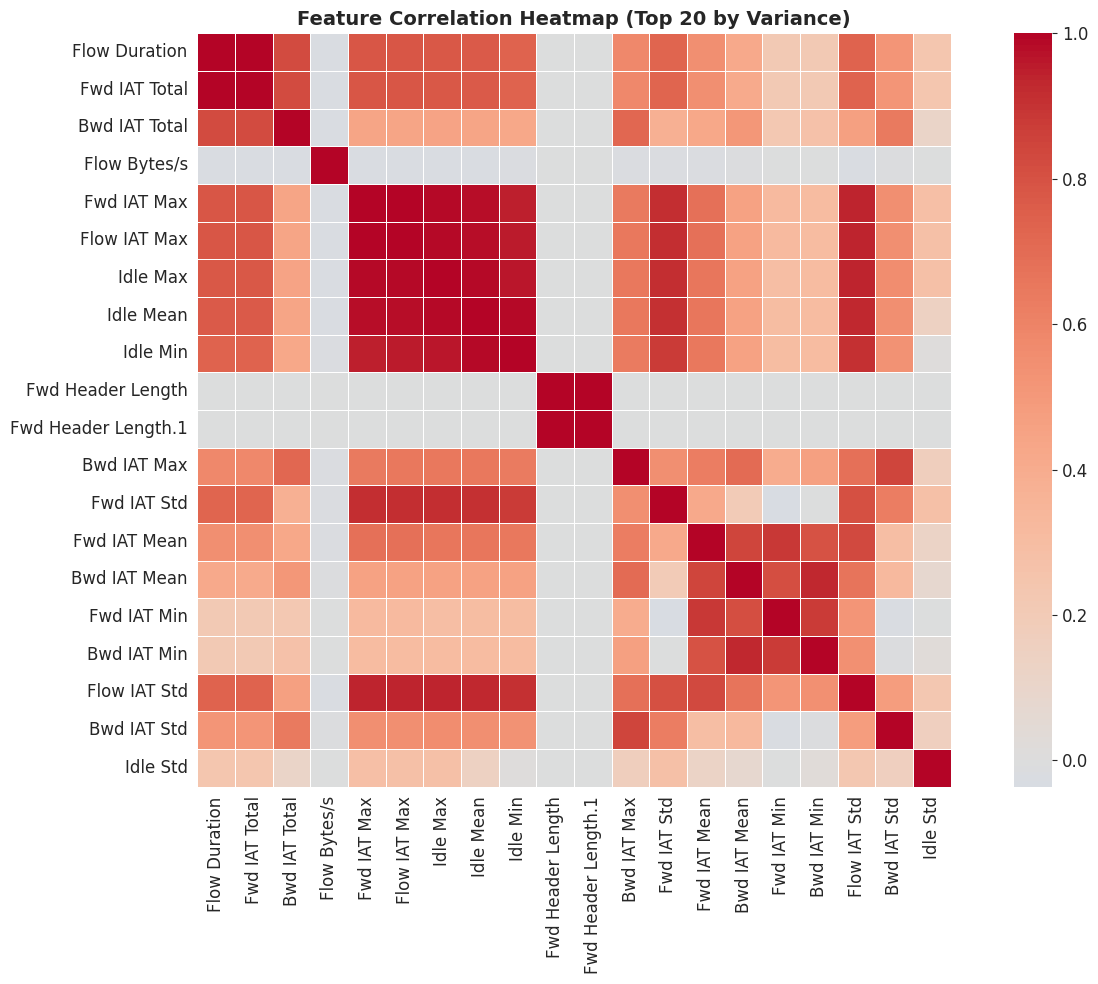

Saved: correlation_heatmap.png


In [36]:
# Feature correlation heatmap (top 20 features by variance)
top_var_cols = data[feature_cols].var().nlargest(20).index.tolist()
corr_matrix = data[top_var_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap (Top 20 by Variance)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: correlation_heatmap.png')

### Explanation:
- Selects the top 20 most variable features to focus on the most informative attributes  
- Computes and visualizes the correlation matrix using a heatmap  
- Helps identify relationships and dependencies between important features  

## 5. Split Data by Network Type (Federated Clients)

In [37]:
print('SPLITTING DATA BY NETWORK TYPE (FEDERATED CLIENTS)')
print('=' * 55)

client_data = {}

for network_name, files in NETWORK_TYPES.items():
    mask = source_files.isin(files)
    client_df = data.loc[mask].copy()

    if len(client_df) == 0:
        print(f'WARNING: {network_name} has no data, skipping.')
        continue

    # Sample for faster training
    n_samples = max(int(len(client_df) * SAMPLE_FRACTION), 1000)
    n_samples = min(n_samples, len(client_df))
    client_df = client_df.sample(n=n_samples, random_state=RANDOM_STATE)

    client_data[network_name] = client_df

    attack_count = client_df['Binary_Label'].sum()
    normal_count = len(client_df) - attack_count
    attack_types = client_df[client_df['Binary_Label'] == 1]['Label'].unique()

    print(f'\nClient: {network_name}')
    print(f'  Samples: {len(client_df):,} (Normal: {normal_count:,}, Attack: {attack_count:,})')
    if len(attack_types) > 0:
        print(f'  Attack types: {', '.join(attack_types)}')
    else:
        print(f'  Attack types: None (pure normal traffic)')

print(f'\nTotal federated clients: {len(client_data)}')

SPLITTING DATA BY NETWORK TYPE (FEDERATED CLIENTS)

Client: Network_A (Normal Traffic)
  Samples: 158,844 (Normal: 158,844, Attack: 0)
  Attack types: None (pure normal traffic)

Client: Network_B (Brute Force)
  Samples: 133,693 (Normal: 129,483, Attack: 4,210)
  Attack types: FTP-Patator, SSH-Patator

Client: Network_C (DoS/Heartbleed)
  Samples: 207,421 (Normal: 131,867, Attack: 75,554)
  Attack types: DoS Hulk, DoS GoldenEye, DoS slowloris, DoS Slowhttptest, Heartbleed

Client: Network_D (Web Attacks/Infiltration)
  Samples: 137,587 (Normal: 136,950, Attack: 637)
  Attack types: Web Attack ï¿½ Brute Force, Web Attack ï¿½ XSS, Web Attack ï¿½ Sql Injection, Infiltration

Client: Network_E (Botnet/PortScan/DDoS)
  Samples: 210,815 (Normal: 124,222, Attack: 86,593)
  Attack types: PortScan, DDoS, Bot

Total federated clients: 5


### Explanation:
- In this step, we split the dataset into multiple subsets to simulate different federated network clients  
- Each client is assigned specific types of network traffic based on source files  
- A sample of data is selected for each client to improve training efficiency  
- Displays the distribution of normal and attack samples for each client  

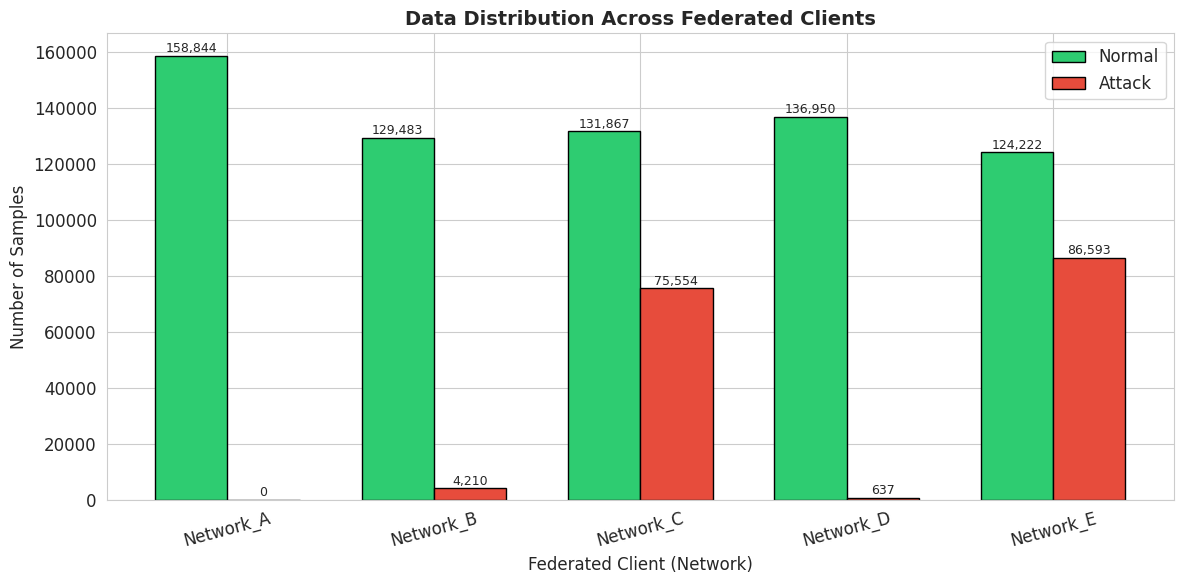

Saved: client_distribution.png


In [38]:
# Visualize client data distribution
fig, ax = plt.subplots(figsize=(12, 6))
client_names = list(client_data.keys())
normal_counts = [len(cd[cd['Binary_Label'] == 0]) for cd in client_data.values()]
attack_counts_list = [len(cd[cd['Binary_Label'] == 1]) for cd in client_data.values()]

x = np.arange(len(client_names))
width = 0.35
bars1 = ax.bar(x - width/2, normal_counts, width, label='Normal', color='#2ecc71', edgecolor='black')
bars2 = ax.bar(x + width/2, attack_counts_list, width, label='Attack', color='#e74c3c', edgecolor='black')

ax.set_xlabel('Federated Client (Network)', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Data Distribution Across Federated Clients', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([n.split('(')[0].strip() for n in client_names], rotation=15)
ax.legend(fontsize=12)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('client_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: client_distribution.png')

### Explanation:
Here, we visualize the distribution of normal and attack samples across different federated clients using a bar chart. This helps in understanding how data is distributed among clients and highlights any imbalance.

## 6. Prepare Global Test Set

In [39]:
# Create a global test set from all clients for fair evaluation
all_client_data = pd.concat(client_data.values(), ignore_index=True)

X_all = all_client_data[feature_cols].values
y_all = all_client_data['Binary_Label'].values

X_train_global, X_test_global, y_train_global, y_test_global = train_test_split(
    X_all, y_all, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_all
)

# Scale features
scaler = StandardScaler()
X_train_global_scaled = scaler.fit_transform(X_train_global)
X_test_global_scaled = scaler.transform(X_test_global)

print(f'Global Train set: {X_train_global.shape[0]:,} samples')
print(f'Global Test set:  {X_test_global.shape[0]:,} samples')
print(f'Train - Normal: {(y_train_global==0).sum():,}, Attack: {(y_train_global==1).sum():,}')
print(f'Test  - Normal: {(y_test_global==0).sum():,}, Attack: {(y_test_global==1).sum():,}')

Global Train set: 678,688 samples
Global Test set:  169,672 samples
Train - Normal: 545,093, Attack: 133,595
Test  - Normal: 136,273, Attack: 33,399


### Explanation:
In this step, we combine data from all federated clients to create a global dataset and split it into training and testing sets. Feature scaling is then applied to ensure consistent model performance during training and evaluation.

## 7. Federated Learning Implementation

### How it works:
1. Each network client trains a **local model** on its own data
2. Only **model parameters/weights** are sent to the central server (no raw data shared)
3. The server performs **Federated Averaging** to create a global model
4. The updated global model is sent back to clients
5. This process repeats for multiple rounds

### Models used:
- **Random Forest** - Ensemble of decision trees for known attack classification
- **XGBoost** - Gradient boosting for high-accuracy classification
- **MLP Neural Network** - Deep learning approach for complex pattern detection
- **Isolation Forest** - Unsupervised anomaly detection for zero-day attacks

### 7.1 Federated Averaging Functions

In [40]:
def federated_avg_random_forest(local_models, n_samples_per_client):
    """
    Federated averaging for Random Forest.
    Uses ensemble voting with adaptive threshold.
    Since each client specializes in different attacks, we lower the
    detection threshold so that if ANY client detects an attack, it is flagged.
    """
    class FederatedRFModel:
        def __init__(self, models, weights):
            self.models = models
            self.weights = weights
            self.classes_ = models[0].classes_
            self.n_clients = len(models)
            # Adaptive threshold: 1/n_clients gives best balance
            self.threshold = 1.0 / self.n_clients
            self.feature_importances_ = np.zeros_like(models[0].feature_importances_)
            for m, w in zip(models, weights):
                self.feature_importances_ += w * m.feature_importances_

        def predict_proba(self, X):
            avg_proba = np.zeros((len(X), 2))
            for model, weight in zip(self.models, self.weights):
                avg_proba += weight * model.predict_proba(X)
            return avg_proba

        def predict(self, X):
            avg_proba = self.predict_proba(X)
            return (avg_proba[:, 1] >= self.threshold).astype(int)

    total = sum(n_samples_per_client)
    weights = [n / total for n in n_samples_per_client]
    return FederatedRFModel(local_models, weights)


def federated_avg_xgboost(local_models, n_samples_per_client, X_train, y_train):
    """
    Federated averaging for XGBoost with adaptive threshold.
    """
    class FederatedXGBModel:
        def __init__(self, models, weights):
            self.models = models
            self.weights = weights
            self.classes_ = np.array([0, 1])
            self.n_clients = len(models)
            self.threshold = 1.0 / self.n_clients
            self.feature_importances_ = np.zeros_like(models[0].feature_importances_)
            for m, w in zip(models, weights):
                self.feature_importances_ += w * m.feature_importances_

        def predict_proba(self, X):
            avg_proba = np.zeros((len(X), 2))
            for model, weight in zip(self.models, self.weights):
                avg_proba += weight * model.predict_proba(X)
            return avg_proba

        def predict(self, X):
            avg_proba = self.predict_proba(X)
            return (avg_proba[:, 1] >= self.threshold).astype(int)

    total = sum(n_samples_per_client)
    weights = [n / total for n in n_samples_per_client]
    return FederatedXGBModel(local_models, weights)


def federated_avg_mlp(local_models, n_samples_per_client):
    """
    Federated averaging for MLP Neural Network.
    Averages the weights (coefs_ and intercepts_) from all local models.
    """
    total_samples = sum(n_samples_per_client)
    global_model = deepcopy(local_models[0])

    avg_coefs = [np.zeros_like(c) for c in global_model.coefs_]
    avg_intercepts = [np.zeros_like(b) for b in global_model.intercepts_]

    for model, n_samples in zip(local_models, n_samples_per_client):
        weight = n_samples / total_samples
        for i in range(len(avg_coefs)):
            avg_coefs[i] += weight * model.coefs_[i]
            avg_intercepts[i] += weight * model.intercepts_[i]

    global_model.coefs_ = avg_coefs
    global_model.intercepts_ = avg_intercepts
    return global_model


def federated_avg_isolation_forest(local_models, n_samples_per_client):
    """
    Federated averaging for Isolation Forest with adaptive threshold.
    """
    class FederatedIFModel:
        def __init__(self, models, weights):
            self.models = models
            self.weights = weights

        def decision_function(self, X):
            avg_scores = np.zeros(len(X))
            for model, weight in zip(self.models, self.weights):
                avg_scores += weight * model.decision_function(X)
            return avg_scores

        def predict(self, X):
            avg_scores = self.decision_function(X)
            return np.where(avg_scores < 0, -1, 1)

    total = sum(n_samples_per_client)
    weights = [n / total for n in n_samples_per_client]
    return FederatedIFModel(local_models, weights)


def evaluate_model(model, X_test, y_test, model_name, is_isolation_forest=False):
    """
    Evaluate model and return metrics dictionary.
    """
    if is_isolation_forest:
        y_pred_raw = model.predict(X_test)
        y_pred = np.where(y_pred_raw == -1, 1, 0)
    else:
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    return {
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'FPR': fpr,
        'y_pred': y_pred
    }


print('Federated averaging functions defined successfully!')

Federated averaging functions defined successfully!


### Explanation:
- Defines federated averaging methods to combine local models from different clients into a single global model  
- Implements separate aggregation strategies for Random Forest, XGBoost, MLP, and Isolation Forest  
- Uses weighted averaging based on client data size and adaptive thresholds for better detection  
- Includes an evaluation function to compute performance metrics such as accuracy, precision, recall, F1-score, and FPR  

### 7.2 Federated Training - Random Forest

In [41]:
print('MODEL 1: FEDERATED RANDOM FOREST')
print('=' * 55)

rf_round_metrics = []

for round_num in range(1, NUM_ROUNDS + 1):
    print(f'\n--- Round {round_num}/{NUM_ROUNDS} ---')
    local_models = []
    n_samples_list = []

    for client_name, client_df in client_data.items():
        X_client = client_df[feature_cols].values
        y_client = client_df['Binary_Label'].values

        if len(np.unique(y_client)) < 2:
            print(f'  {client_name}: skipped (single class)')
            continue

        local_rf = RandomForestClassifier(
            n_estimators=100, max_depth=15, random_state=RANDOM_STATE + round_num,
            class_weight='balanced', n_jobs=-1
        )
        local_rf.fit(X_client, y_client)
        local_models.append(local_rf)
        n_samples_list.append(len(X_client))
        local_acc = accuracy_score(y_client, local_rf.predict(X_client))
        print(f'  {client_name}: trained ({len(X_client):,} samples, local acc: {local_acc:.4f})')

    # Federated Averaging - ensemble voting across all client models
    global_rf = federated_avg_random_forest(local_models, n_samples_list)
    metrics = evaluate_model(global_rf, X_test_global, y_test_global, 'Random Forest')
    rf_round_metrics.append({'Round': round_num, **{k: v for k, v in metrics.items() if k != 'y_pred'}})
    print(f'  Global Model -> Acc: {metrics["Accuracy"]:.4f}, F1: {metrics["F1-Score"]:.4f}, FPR: {metrics["FPR"]:.4f}')

rf_final_metrics = evaluate_model(global_rf, X_test_global, y_test_global, 'Random Forest')
print(f'\nFinal Random Forest Performance:')
print(f'  Accuracy:  {rf_final_metrics["Accuracy"]:.4f}')
print(f'  Precision: {rf_final_metrics["Precision"]:.4f}')
print(f'  Recall:    {rf_final_metrics["Recall"]:.4f}')
print(f'  F1-Score:  {rf_final_metrics["F1-Score"]:.4f}')
print(f'  FPR:       {rf_final_metrics["FPR"]:.4f}')

MODEL 1: FEDERATED RANDOM FOREST

--- Round 1/5 ---
  Network_A (Normal Traffic): skipped (single class)
  Network_B (Brute Force): trained (133,693 samples, local acc: 1.0000)
  Network_C (DoS/Heartbleed): trained (207,421 samples, local acc: 0.9997)
  Network_D (Web Attacks/Infiltration): trained (137,587 samples, local acc: 1.0000)
  Network_E (Botnet/PortScan/DDoS): trained (210,815 samples, local acc: 0.9997)
  Global Model -> Acc: 0.9954, F1: 0.9882, FPR: 0.0007

--- Round 2/5 ---
  Network_A (Normal Traffic): skipped (single class)
  Network_B (Brute Force): trained (133,693 samples, local acc: 1.0000)
  Network_C (DoS/Heartbleed): trained (207,421 samples, local acc: 0.9997)
  Network_D (Web Attacks/Infiltration): trained (137,587 samples, local acc: 1.0000)
  Network_E (Botnet/PortScan/DDoS): trained (210,815 samples, local acc: 0.9996)
  Global Model -> Acc: 0.9951, F1: 0.9875, FPR: 0.0007

--- Round 3/5 ---
  Network_A (Normal Traffic): skipped (single class)
  Network_B (Br

### Explanation:
- In this step, we train Random Forest models locally on each federated client using their respective data  
- The trained local models are aggregated using federated averaging to create a global model  
- The process is repeated for multiple rounds to improve performance  
- Finally, the global model is evaluated using metrics like accuracy, precision, recall, F1-score, and FPR  

### 7.3 Federated Training - XGBoost

In [44]:
print('MODEL 2: FEDERATED XGBOOST')
print('=' * 55)

xgb_round_metrics = []

for round_num in range(1, NUM_ROUNDS + 1):
    print(f'\n--- Round {round_num}/{NUM_ROUNDS} ---')
    local_models = []
    n_samples_list = []

    for client_name, client_df in client_data.items():
        X_client = client_df[feature_cols].values
        y_client = client_df['Binary_Label'].values

        if len(np.unique(y_client)) < 2:
            print(f'  {client_name}: skipped (single class)')
            continue

        n_normal = (y_client == 0).sum()
        n_attack = max((y_client == 1).sum(), 1)
        spw = n_normal / n_attack

        local_xgb = XGBClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            scale_pos_weight=spw,
            random_state=RANDOM_STATE + round_num, eval_metric='logloss', verbosity=0
        )
        local_xgb.fit(X_client, y_client)
        local_models.append(local_xgb)
        n_samples_list.append(len(X_client))
        local_acc = accuracy_score(y_client, local_xgb.predict(X_client))
        print(f'  {client_name}: trained ({len(X_client):,} samples, local acc: {local_acc:.4f})')

    # Federated Averaging - ensemble voting across all client models
    global_xgb = federated_avg_xgboost(local_models, n_samples_list, X_train_global, y_train_global)
    metrics = evaluate_model(global_xgb, X_test_global, y_test_global, 'XGBoost')
    xgb_round_metrics.append({'Round': round_num, **{k: v for k, v in metrics.items() if k != 'y_pred'}})
    print(f'  Global Model -> Acc: {metrics["Accuracy"]:.4f}, F1: {metrics["F1-Score"]:.4f}, FPR: {metrics["FPR"]:.4f}')

xgb_final_metrics = evaluate_model(global_xgb, X_test_global, y_test_global, 'XGBoost')
print(f'\nFinal XGBoost Performance:')
print(f'  Accuracy:  {xgb_final_metrics["Accuracy"]:.4f}')
print(f'  Precision: {xgb_final_metrics["Precision"]:.4f}')
print(f'  Recall:    {xgb_final_metrics["Recall"]:.4f}')
print(f'  F1-Score:  {xgb_final_metrics["F1-Score"]:.4f}')
print(f'  FPR:       {xgb_final_metrics["FPR"]:.4f}')


MODEL 2: FEDERATED XGBOOST

--- Round 1/5 ---
  Network_A (Normal Traffic): skipped (single class)
  Network_B (Brute Force): trained (133,693 samples, local acc: 1.0000)
  Network_C (DoS/Heartbleed): trained (207,421 samples, local acc: 0.9998)
  Network_D (Web Attacks/Infiltration): trained (137,587 samples, local acc: 1.0000)
  Network_E (Botnet/PortScan/DDoS): trained (210,815 samples, local acc: 0.9991)
  Global Model -> Acc: 0.9829, F1: 0.9574, FPR: 0.0153

--- Round 2/5 ---
  Network_A (Normal Traffic): skipped (single class)
  Network_B (Brute Force): trained (133,693 samples, local acc: 1.0000)
  Network_C (DoS/Heartbleed): trained (207,421 samples, local acc: 0.9998)
  Network_D (Web Attacks/Infiltration): trained (137,587 samples, local acc: 1.0000)
  Network_E (Botnet/PortScan/DDoS): trained (210,815 samples, local acc: 0.9991)
  Global Model -> Acc: 0.9829, F1: 0.9574, FPR: 0.0153

--- Round 3/5 ---
  Network_A (Normal Traffic): skipped (single class)
  Network_B (Brute Fo

### Explanation:
- In this step, we train XGBoost models on each federated client with class imbalance handling using scale_pos_weight  
- Local models are aggregated using federated averaging to form a global XGBoost model  
- The training is performed over multiple rounds to improve learning  
- Finally, the global model is evaluated using performance metrics such as accuracy, precision, recall, F1-score, and FPR  

### 7.4 Federated Training - MLP Neural Network

In [45]:
print('MODEL 3: FEDERATED MLP NEURAL NETWORK')
print('=' * 55)

mlp_round_metrics = []
global_mlp = None

for round_num in range(1, NUM_ROUNDS + 1):
    print(f'\n--- Round {round_num}/{NUM_ROUNDS} ---')
    local_models = []
    n_samples_list = []

    for client_name, client_df in client_data.items():
        X_client = client_df[feature_cols].values
        y_client = client_df['Binary_Label'].values

        if len(np.unique(y_client)) < 2:
            print(f'  {client_name}: skipped (single class)')
            continue

        client_scaler = StandardScaler()
        X_client_scaled = client_scaler.fit_transform(X_client)

        # Subsample for speed (max 20000)
        if len(X_client_scaled) > 20000:
            idx = np.random.RandomState(RANDOM_STATE + round_num).choice(
                len(X_client_scaled), size=20000, replace=False
            )
            X_mlp = X_client_scaled[idx]
            y_mlp = y_client[idx]
        else:
            X_mlp = X_client_scaled
            y_mlp = y_client

        # Oversample minority class (attack) to balance training data
        n_attack = (y_mlp == 1).sum()
        n_normal = (y_mlp == 0).sum()
        if n_attack > 0 and n_normal > n_attack:
            attack_idx = np.where(y_mlp == 1)[0]
            normal_idx = np.where(y_mlp == 0)[0]
            oversampled_attack_idx = np.random.RandomState(RANDOM_STATE + round_num).choice(
                attack_idx, size=n_normal, replace=True
            )
            balanced_idx = np.concatenate([normal_idx, oversampled_attack_idx])
            np.random.RandomState(RANDOM_STATE).shuffle(balanced_idx)
            X_mlp = X_mlp[balanced_idx]
            y_mlp = y_mlp[balanced_idx]

        if global_mlp is not None:
            local_mlp = MLPClassifier(
                hidden_layer_sizes=(128, 64, 32), max_iter=50, activation='relu',
                solver='adam', random_state=RANDOM_STATE + round_num,
                warm_start=True, early_stopping=False
            )
            local_mlp.fit(X_mlp, y_mlp)
            local_mlp.coefs_ = deepcopy(global_mlp.coefs_)
            local_mlp.intercepts_ = deepcopy(global_mlp.intercepts_)
            local_mlp.fit(X_mlp, y_mlp)
        else:
            local_mlp = MLPClassifier(
                hidden_layer_sizes=(128, 64, 32), max_iter=100, activation='relu',
                solver='adam', random_state=RANDOM_STATE + round_num,
                early_stopping=True, validation_fraction=0.1
            )
            local_mlp.fit(X_mlp, y_mlp)

        local_models.append(local_mlp)
        n_samples_list.append(len(X_mlp))
        local_acc = accuracy_score(y_mlp, local_mlp.predict(X_mlp))
        print(f'  {client_name}: trained ({len(X_mlp):,} samples, local acc: {local_acc:.4f})')

    # Federated Averaging - average neural network weights
    global_mlp = federated_avg_mlp(local_models, n_samples_list)
    metrics = evaluate_model(global_mlp, X_test_global_scaled, y_test_global, 'MLP Neural Network')
    mlp_round_metrics.append({'Round': round_num, **{k: v for k, v in metrics.items() if k != 'y_pred'}})
    print(f'  Global Model -> Acc: {metrics["Accuracy"]:.4f}, F1: {metrics["F1-Score"]:.4f}, FPR: {metrics["FPR"]:.4f}')

mlp_final_metrics = evaluate_model(global_mlp, X_test_global_scaled, y_test_global, 'MLP Neural Network')
print(f'\nFinal MLP Neural Network Performance:')
print(f'  Accuracy:  {mlp_final_metrics["Accuracy"]:.4f}')
print(f'  Precision: {mlp_final_metrics["Precision"]:.4f}')
print(f'  Recall:    {mlp_final_metrics["Recall"]:.4f}')
print(f'  F1-Score:  {mlp_final_metrics["F1-Score"]:.4f}')
print(f'  FPR:       {mlp_final_metrics["FPR"]:.4f}')

MODEL 3: FEDERATED MLP NEURAL NETWORK

--- Round 1/5 ---
  Network_A (Normal Traffic): skipped (single class)
  Network_B (Brute Force): trained (38,768 samples, local acc: 0.9989)
  Network_C (DoS/Heartbleed): trained (25,360 samples, local acc: 0.9933)
  Network_D (Web Attacks/Infiltration): trained (39,822 samples, local acc: 0.9967)
  Network_E (Botnet/PortScan/DDoS): trained (23,702 samples, local acc: 0.9957)
  Global Model -> Acc: 0.8031, F1: 0.0026, FPR: 0.0004

--- Round 2/5 ---
  Network_A (Normal Traffic): skipped (single class)
  Network_B (Brute Force): trained (38,704 samples, local acc: 0.9974)
  Network_C (DoS/Heartbleed): trained (25,484 samples, local acc: 0.9803)
  Network_D (Web Attacks/Infiltration): trained (39,796 samples, local acc: 0.9975)
  Network_E (Botnet/PortScan/DDoS): trained (23,760 samples, local acc: 0.9843)
  Global Model -> Acc: 0.8281, F1: 0.3944, FPR: 0.0387

--- Round 3/5 ---
  Network_A (Normal Traffic): skipped (single class)
  Network_B (Brute

### Explanation:
- In this step, we train MLP neural network models on each client with feature scaling and subsampling for efficiency  
- Class imbalance is handled using oversampling of attack samples  
- Model weights are shared and averaged across clients using federated learning  
- The final global model is evaluated using accuracy, precision, recall, F1-score, and FPR  

### 7.5 Federated Training - Isolation Forest (Anomaly Detection)

In [46]:
print('MODEL 4: FEDERATED ISOLATION FOREST (ANOMALY DETECTION)')
print('=' * 55)

if_round_metrics = []

for round_num in range(1, NUM_ROUNDS + 1):
    print(f'\n--- Round {round_num}/{NUM_ROUNDS} ---')
    local_models = []
    n_samples_list = []

    for client_name, client_df in client_data.items():
        X_client = client_df[feature_cols].values
        y_client = client_df['Binary_Label'].values

        client_scaler = StandardScaler()
        X_client_scaled = client_scaler.fit_transform(X_client)

        # Dynamic contamination based on actual attack ratio
        attack_ratio = max((y_client == 1).sum() / len(y_client), 0.01)
        attack_ratio = min(attack_ratio, 0.5)

        local_if = IsolationForest(
            n_estimators=100, contamination=attack_ratio,
            random_state=RANDOM_STATE + round_num, n_jobs=-1
        )
        local_if.fit(X_client_scaled)
        local_models.append(local_if)
        n_samples_list.append(len(X_client))

        y_pred_local = np.where(local_if.predict(X_client_scaled) == -1, 1, 0)
        local_acc = accuracy_score(y_client, y_pred_local)
        print(f'  {client_name}: trained ({len(X_client):,} samples, contamination: {attack_ratio:.3f}, local acc: {local_acc:.4f})')

    # Federated Averaging - ensemble of anomaly detectors
    global_if = federated_avg_isolation_forest(local_models, n_samples_list)
    metrics = evaluate_model(global_if, X_test_global_scaled, y_test_global, 'Isolation Forest', is_isolation_forest=True)
    if_round_metrics.append({'Round': round_num, **{k: v for k, v in metrics.items() if k != 'y_pred'}})
    print(f'  Global Model -> Acc: {metrics["Accuracy"]:.4f}, F1: {metrics["F1-Score"]:.4f}, FPR: {metrics["FPR"]:.4f}')

if_final_metrics = evaluate_model(global_if, X_test_global_scaled, y_test_global, 'Isolation Forest', is_isolation_forest=True)
print(f'\nFinal Isolation Forest Performance:')
print(f'  Accuracy:  {if_final_metrics["Accuracy"]:.4f}')
print(f'  Precision: {if_final_metrics["Precision"]:.4f}')
print(f'  Recall:    {if_final_metrics["Recall"]:.4f}')
print(f'  F1-Score:  {if_final_metrics["F1-Score"]:.4f}')
print(f'  FPR:       {if_final_metrics["FPR"]:.4f}')

MODEL 4: FEDERATED ISOLATION FOREST (ANOMALY DETECTION)

--- Round 1/5 ---
  Network_A (Normal Traffic): trained (158,844 samples, contamination: 0.010, local acc: 0.9900)
  Network_B (Brute Force): trained (133,693 samples, contamination: 0.031, local acc: 0.9370)
  Network_C (DoS/Heartbleed): trained (207,421 samples, contamination: 0.364, local acc: 0.7406)
  Network_D (Web Attacks/Infiltration): trained (137,587 samples, contamination: 0.010, local acc: 0.9855)
  Network_E (Botnet/PortScan/DDoS): trained (210,815 samples, contamination: 0.411, local acc: 0.4636)
  Global Model -> Acc: 0.8067, F1: 0.4389, FPR: 0.0897

--- Round 2/5 ---
  Network_A (Normal Traffic): trained (158,844 samples, contamination: 0.010, local acc: 0.9900)
  Network_B (Brute Force): trained (133,693 samples, contamination: 0.031, local acc: 0.9370)
  Network_C (DoS/Heartbleed): trained (207,421 samples, contamination: 0.364, local acc: 0.7345)
  Network_D (Web Attacks/Infiltration): trained (137,587 samples,

### Explanation:
- In this step, we train Isolation Forest models on each client to detect anomalies and unknown attacks  
- A dynamic contamination rate is used based on the proportion of attack data in each client  
- Local anomaly detection models are combined using federated averaging  
- The global model is evaluated using accuracy, precision, recall, F1-score, and FPR  

## 8. Results Comparison and Visualization

In [47]:
# Compile all results
all_metrics = []
for m in [rf_final_metrics, xgb_final_metrics, mlp_final_metrics, if_final_metrics]:
    all_metrics.append({k: v for k, v in m.items() if k != 'y_pred'})

results_df = pd.DataFrame(all_metrics)
results_df = results_df.set_index('Model')

print('\n' + '=' * 70)
print('FINAL MODEL COMPARISON - FEDERATED LEARNING IDS')
print('=' * 70)
print(results_df.to_string(float_format='{:.4f}'.format))
print('=' * 70)


FINAL MODEL COMPARISON - FEDERATED LEARNING IDS
                    Accuracy  Precision  Recall  F1-Score    FPR
Model                                                           
Random Forest         0.9960     0.9971  0.9825    0.9898 0.0007
XGBoost               0.9829     0.9400  0.9754    0.9574 0.0153
MLP Neural Network    0.8674     0.9614  0.3402    0.5026 0.0033
Isolation Forest      0.7973     0.4801  0.3566    0.4092 0.0946


### Explanation:
Here, we compile the performance metrics of all models into a single dataframe for comparison. It provides a clear summary of how each model performs in the federated learning setup.

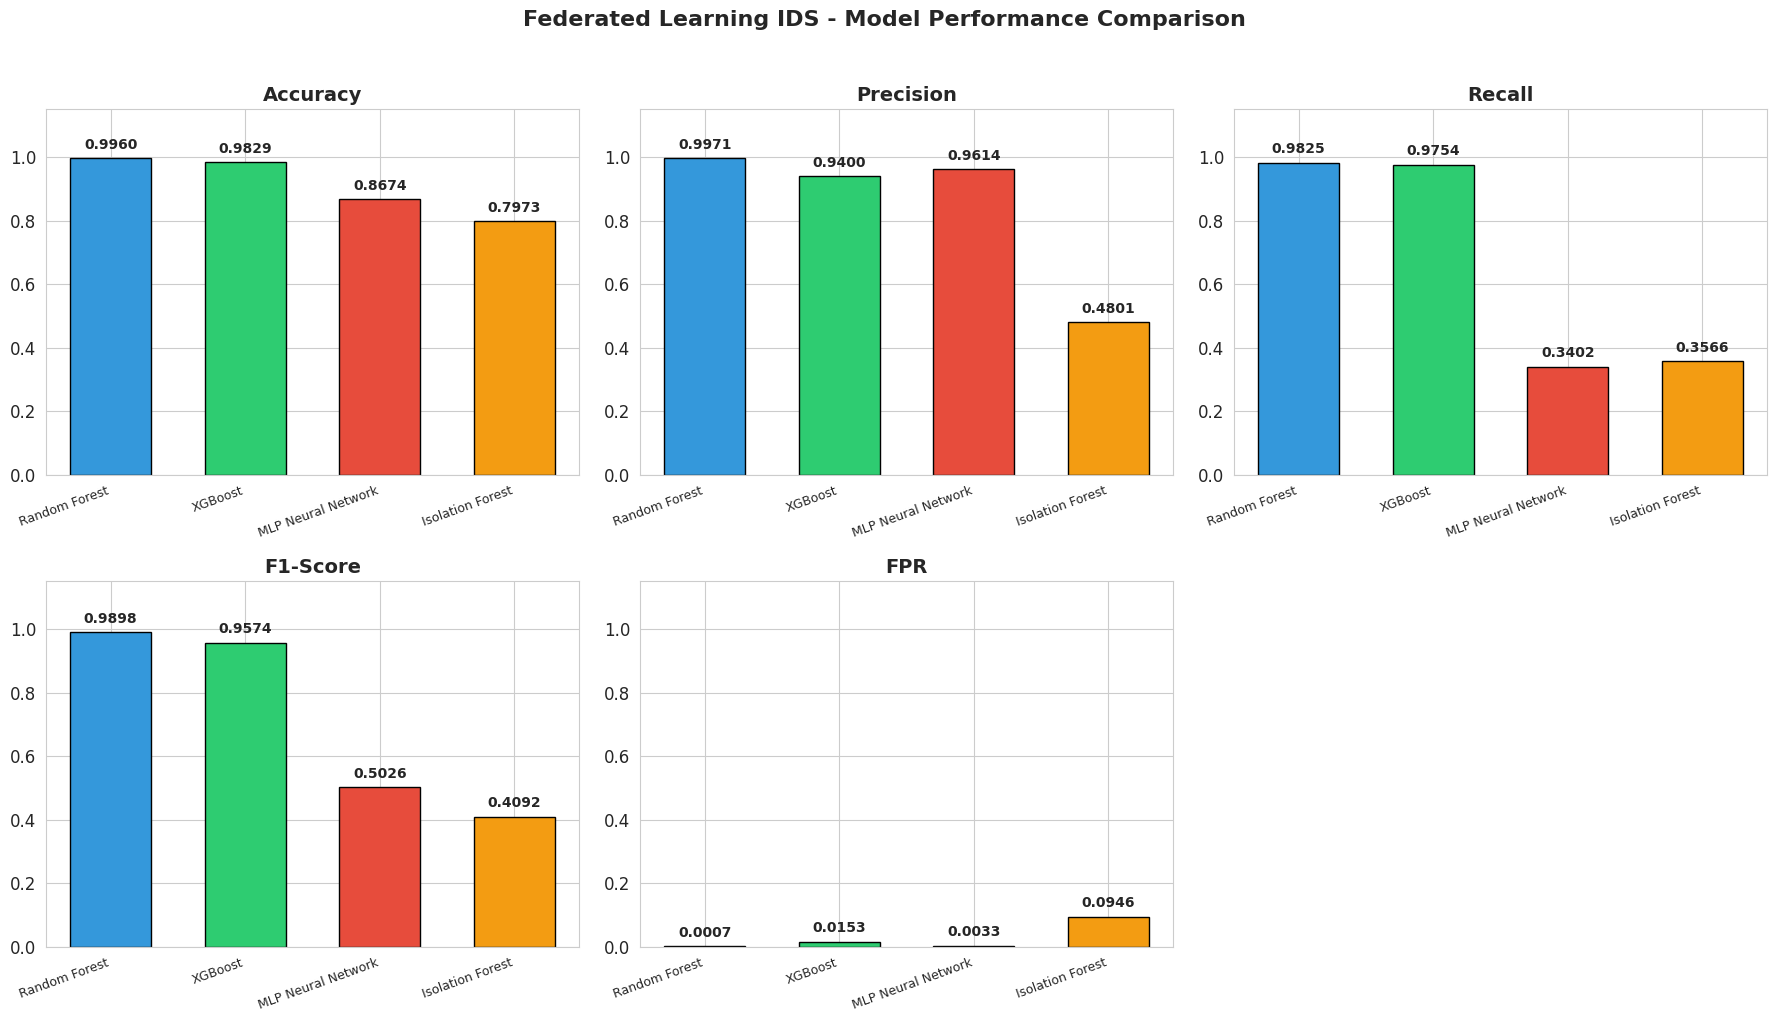

Saved: model_comparison.png


In [48]:
# Bar chart comparison of all metrics
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'FPR']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
model_names = results_df.index.tolist()

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 3][idx % 3]
    values = results_df[metric].values
    bars = ax.bar(model_names, values, color=colors, edgecolor='black', width=0.6)
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Remove empty subplot
axes[1][2].axis('off')

plt.suptitle('Federated Learning IDS - Model Performance Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison.png')

### Explanation:
Here, we visualize and compare the performance of all models across different evaluation metrics using bar charts. This helps in easily identifying the best-performing model in the federated learning framework.

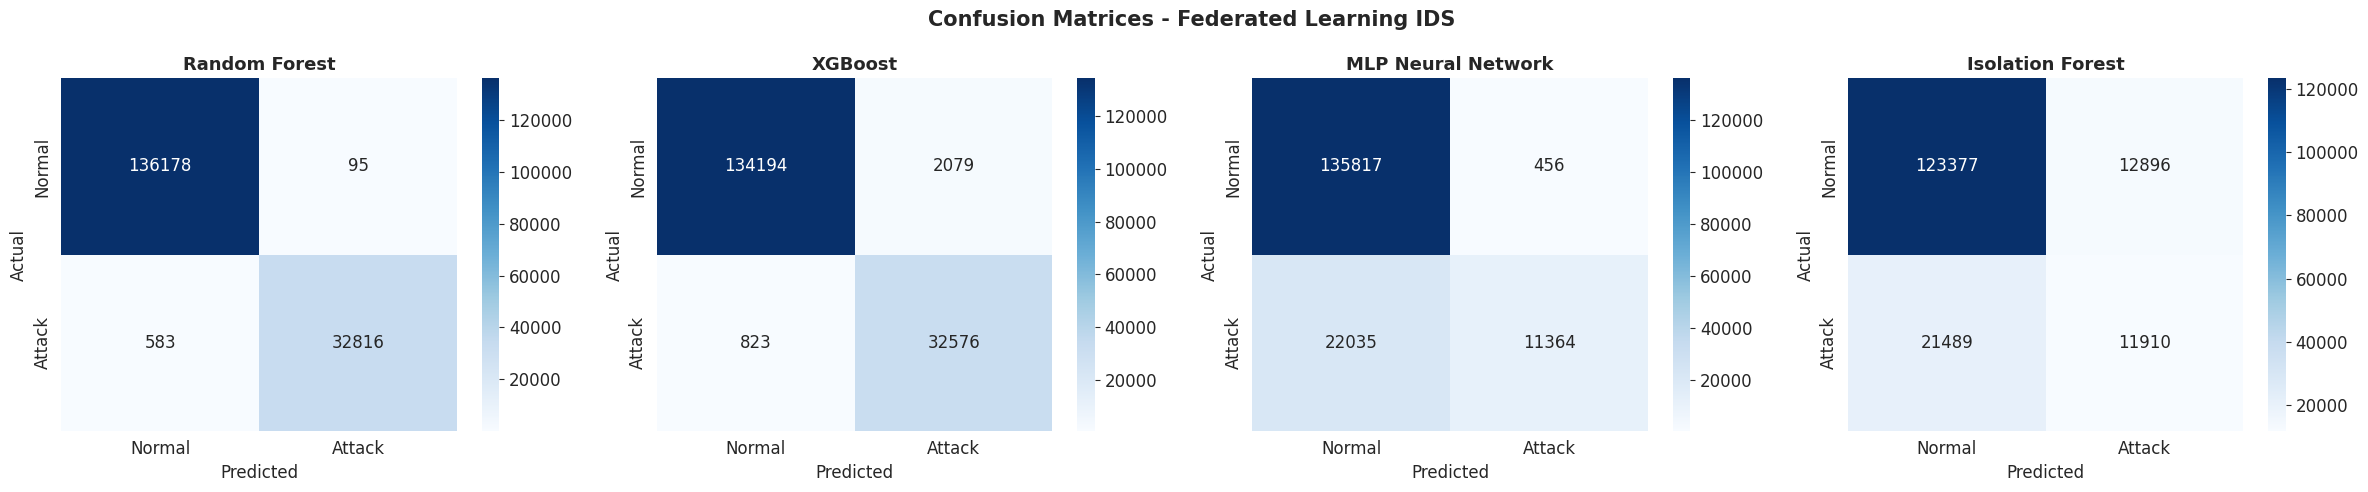

Saved: confusion_matrices.png


In [49]:
# Confusion Matrices for all models
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

all_preds = [
    ('Random Forest', rf_final_metrics['y_pred']),
    ('XGBoost', xgb_final_metrics['y_pred']),
    ('MLP Neural Network', mlp_final_metrics['y_pred']),
    ('Isolation Forest', if_final_metrics['y_pred'])
]

for idx, (name, y_pred) in enumerate(all_preds):
    cm = confusion_matrix(y_test_global, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
    axes[idx].set_title(f'{name}', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.suptitle('Confusion Matrices - Federated Learning IDS', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices.png')

### Explanation:
Here, we generate confusion matrices for all models to evaluate their prediction performance in terms of correct and incorrect classifications. This helps in understanding model accuracy, false positives, and false negatives more clearly.

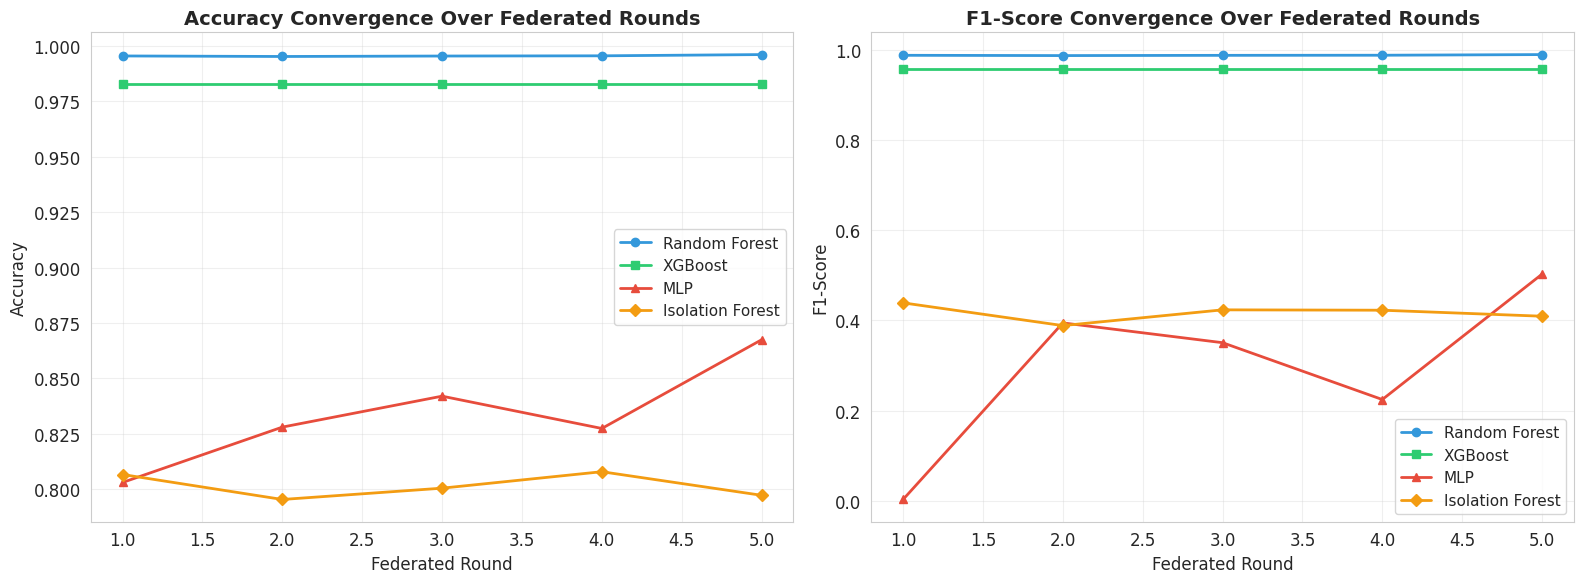

Saved: federated_convergence.png


In [50]:
# Federated Learning convergence - Accuracy across rounds
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rf_df = pd.DataFrame(rf_round_metrics)
xgb_df = pd.DataFrame(xgb_round_metrics)
mlp_df = pd.DataFrame(mlp_round_metrics)
if_df = pd.DataFrame(if_round_metrics)

# Accuracy over rounds
axes[0].plot(rf_df['Round'], rf_df['Accuracy'], 'o-', label='Random Forest', color='#3498db', linewidth=2)
axes[0].plot(xgb_df['Round'], xgb_df['Accuracy'], 's-', label='XGBoost', color='#2ecc71', linewidth=2)
axes[0].plot(mlp_df['Round'], mlp_df['Accuracy'], '^-', label='MLP', color='#e74c3c', linewidth=2)
axes[0].plot(if_df['Round'], if_df['Accuracy'], 'D-', label='Isolation Forest', color='#f39c12', linewidth=2)
axes[0].set_xlabel('Federated Round', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Accuracy Convergence Over Federated Rounds', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# F1-Score over rounds
axes[1].plot(rf_df['Round'], rf_df['F1-Score'], 'o-', label='Random Forest', color='#3498db', linewidth=2)
axes[1].plot(xgb_df['Round'], xgb_df['F1-Score'], 's-', label='XGBoost', color='#2ecc71', linewidth=2)
axes[1].plot(mlp_df['Round'], mlp_df['F1-Score'], '^-', label='MLP', color='#e74c3c', linewidth=2)
axes[1].plot(if_df['Round'], if_df['F1-Score'], 'D-', label='Isolation Forest', color='#f39c12', linewidth=2)
axes[1].set_xlabel('Federated Round', fontsize=12)
axes[1].set_ylabel('F1-Score', fontsize=12)
axes[1].set_title('F1-Score Convergence Over Federated Rounds', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('federated_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: federated_convergence.png')

### Explanation:
Here, we visualize how model performance improves over federated learning rounds using accuracy and F1-score plots. This helps in understanding the convergence and learning progress of each model.

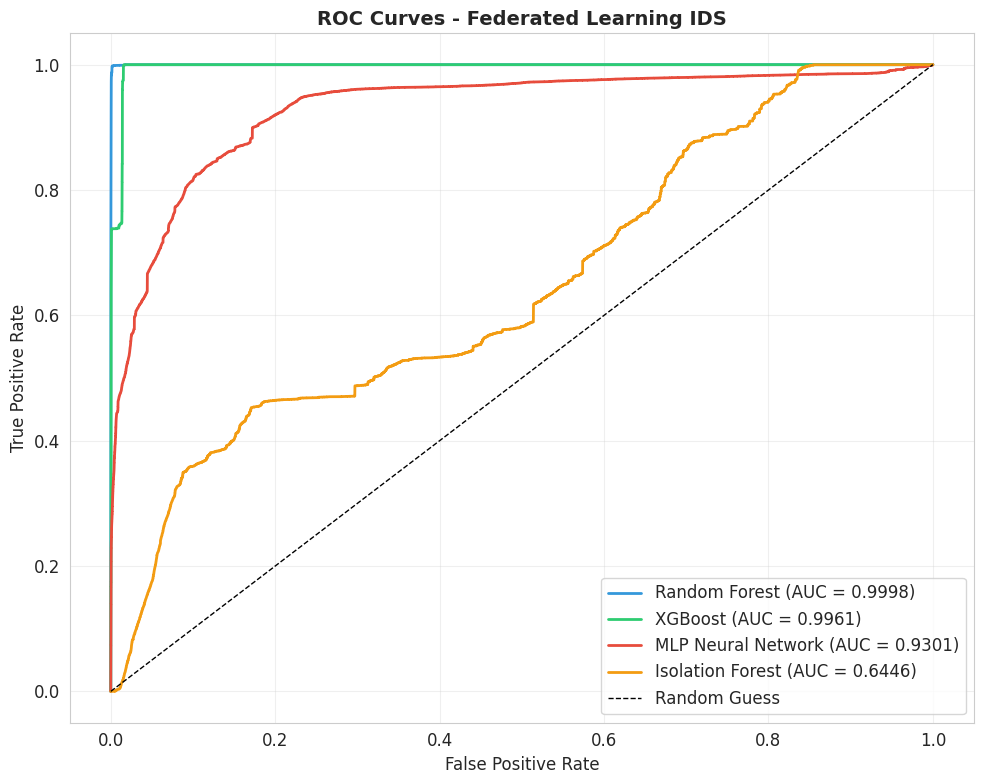

Saved: roc_curves.png


In [51]:
# ROC Curves
fig, ax = plt.subplots(figsize=(10, 8))

roc_data = [
    ('Random Forest', global_rf, X_test_global, False),
    ('XGBoost', global_xgb, X_test_global, False),
    ('MLP Neural Network', global_mlp, X_test_global_scaled, False),
    ('Isolation Forest', global_if, X_test_global_scaled, True)
]
colors_roc = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for (name, model, X_test, is_if), color in zip(roc_data, colors_roc):
    if is_if:
        # Isolation Forest: use decision_function scores (more negative = more anomalous)
        y_scores = -model.decision_function(X_test)  # Negate so anomaly gets higher score
    elif hasattr(model, 'predict_proba'):
        y_scores = model.predict_proba(X_test)[:, 1]
    else:
        continue

    fpr_curve, tpr_curve, _ = roc_curve(y_test_global, y_scores)
    roc_auc = auc(fpr_curve, tpr_curve)
    ax.plot(fpr_curve, tpr_curve, color=color, linewidth=2,
            label=f'{name} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - Federated Learning IDS', fontsize=14, fontweight='bold')
ax.legend(fontsize=12, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: roc_curves.png')

### Explanation:
Here, we plot ROC curves for all models to evaluate their ability to distinguish between normal and attack traffic. The AUC score helps compare overall model performance, where higher values indicate better classification.

## 9. Classification Reports

In [52]:
for name, y_pred in all_preds:
    print(f'\n{"=" * 55}')
    print(f'Classification Report: {name}')
    print('=' * 55)
    print(classification_report(y_test_global, y_pred, target_names=['Normal', 'Attack']))


Classification Report: Random Forest
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    136273
      Attack       1.00      0.98      0.99     33399

    accuracy                           1.00    169672
   macro avg       1.00      0.99      0.99    169672
weighted avg       1.00      1.00      1.00    169672


Classification Report: XGBoost
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.99    136273
      Attack       0.94      0.98      0.96     33399

    accuracy                           0.98    169672
   macro avg       0.97      0.98      0.97    169672
weighted avg       0.98      0.98      0.98    169672


Classification Report: MLP Neural Network
              precision    recall  f1-score   support

      Normal       0.86      1.00      0.92    136273
      Attack       0.96      0.34      0.50     33399

    accuracy                           0.87    169672
   macro avg   

### Explanation:
Here, we generate classification reports for each model to evaluate detailed performance metrics. It provides precision, recall, F1-score, and support for both normal and attack classes.

## 10. Feature Importance Analysis

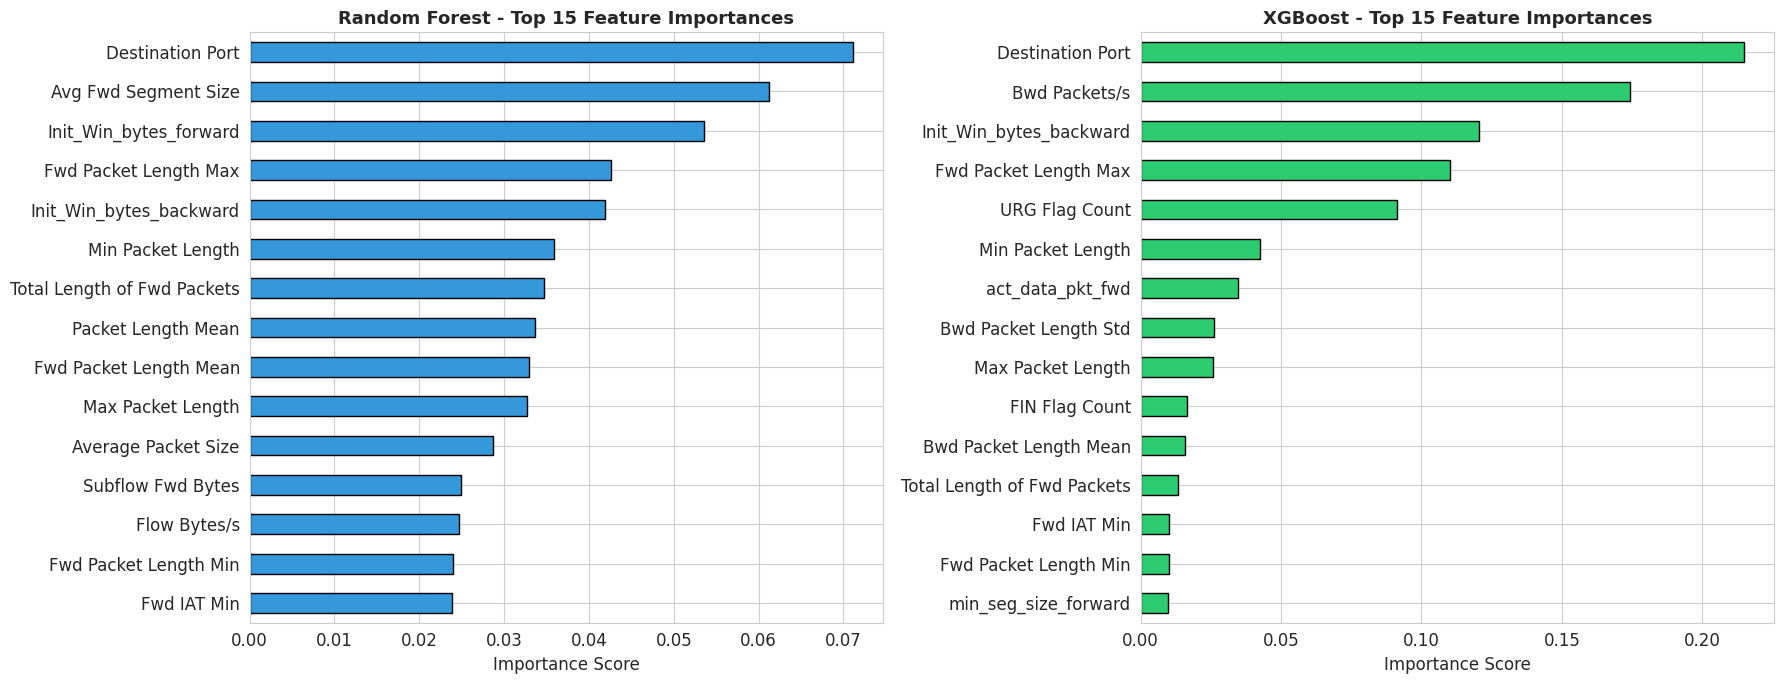

Saved: feature_importance.png


In [53]:
# Random Forest Feature Importance
rf_importance = pd.Series(global_rf.feature_importances_, index=feature_cols)
top_features = rf_importance.nlargest(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Random Forest
top_features.sort_values().plot(kind='barh', ax=axes[0], color='#3498db', edgecolor='black')
axes[0].set_title('Random Forest - Top 15 Feature Importances', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Importance Score')

# XGBoost Feature Importance
xgb_importance = pd.Series(global_xgb.feature_importances_, index=feature_cols)
top_xgb_features = xgb_importance.nlargest(15)
top_xgb_features.sort_values().plot(kind='barh', ax=axes[1], color='#2ecc71', edgecolor='black')
axes[1].set_title('XGBoost - Top 15 Feature Importances', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_importance.png')

### Explanation:
Here, we analyze and visualize the top important features used by Random Forest and XGBoost models. This helps in understanding which features contribute most to intrusion detection.

## 11. Intrusion Alert System Simulation

In [54]:
# Simulate real-time intrusion detection alerts using the best model
print('INTRUSION DETECTION ALERT SYSTEM')
print('=' * 55)
print('Analyzing network traffic samples using federated global model...\n')

# Use Random Forest (best supervised model) for alerts
sample_indices = np.random.RandomState(42).choice(len(X_test_global), size=20, replace=False)
X_sample = X_test_global[sample_indices]
y_true_sample = y_test_global[sample_indices]
y_pred_sample = global_rf.predict(X_sample)

alert_count = 0
for i in range(len(X_sample)):
    status = 'ATTACK DETECTED' if y_pred_sample[i] == 1 else 'Normal'
    actual = 'Attack' if y_true_sample[i] == 1 else 'Normal'
    match = 'CORRECT' if y_pred_sample[i] == y_true_sample[i] else 'MISSED'
    
    if y_pred_sample[i] == 1:
        alert_count += 1
        print(f'  [ALERT #{alert_count:02d}] Packet {i+1:02d}: {status} | Actual: {actual} | {match}')
    else:
        print(f'  [  OK  ] Packet {i+1:02d}: {status} | Actual: {actual} | {match}')

print(f'\nTotal alerts generated: {alert_count}/20 packets')
print(f'Detection accuracy on sample: {accuracy_score(y_true_sample, y_pred_sample):.2%}')

INTRUSION DETECTION ALERT SYSTEM
Analyzing network traffic samples using federated global model...

  [  OK  ] Packet 01: Normal | Actual: Attack | MISSED
  [ALERT #01] Packet 02: ATTACK DETECTED | Actual: Attack | CORRECT
  [  OK  ] Packet 03: Normal | Actual: Normal | CORRECT
  [  OK  ] Packet 04: Normal | Actual: Normal | CORRECT
  [  OK  ] Packet 05: Normal | Actual: Normal | CORRECT
  [  OK  ] Packet 06: Normal | Actual: Normal | CORRECT
  [  OK  ] Packet 07: Normal | Actual: Normal | CORRECT
  [ALERT #02] Packet 08: ATTACK DETECTED | Actual: Attack | CORRECT
  [  OK  ] Packet 09: Normal | Actual: Normal | CORRECT
  [  OK  ] Packet 10: Normal | Actual: Normal | CORRECT
  [  OK  ] Packet 11: Normal | Actual: Normal | CORRECT
  [  OK  ] Packet 12: Normal | Actual: Normal | CORRECT
  [  OK  ] Packet 13: Normal | Actual: Normal | CORRECT
  [ALERT #03] Packet 14: ATTACK DETECTED | Actual: Attack | CORRECT
  [  OK  ] Packet 15: Normal | Actual: Normal | CORRECT
  [  OK  ] Packet 16: Nor

### Explanation:
Here, we simulate a real-time intrusion detection system using the trained global Random Forest model on sample network data. It generates alerts for detected attacks and evaluates prediction accuracy on the sampled traffic.